In [1]:
!pip install cosmopower gdown cython camb

In [2]:
!git clone https://github.com/lesgourg/class_public
%cd class_public
!make clean
!make
%cd python 
!python setup.py build
!python setup.py install

fatal: destination path 'class_public' already exists and is not an empty directory.


⚡️ Tip	Connect GitHub to Studios: https://lightning.ai/adrita/home?settings=integrations

/teamspace/studios/this_studio/class_public
rm -rf /teamspace/studios/this_studio/class_public/build;
rm -f libclass.a
rm -f /teamspace/studios/this_studio/class_public/python/classy.c
rm -rf /teamspace/studios/this_studio/class_public/python/build


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


if ! [ -e /teamspace/studios/this_studio/class_public/build ]; then mkdir /teamspace/studios/this_studio/class_public/build ; mkdir /teamspace/studios/this_studio/class_public/build/lib; fi;
touch build/.base
cd /teamspace/studios/this_studio/class_public/build;gcc -O3 -pthread  -g -fPIC -D__CLASSDIR__='"/teamspace/studios/this_studio/class_public"' -DHYREC -I../include -I../external/RecfastCLASS -I../external/heating -I../external/HyRec2020 -I../external/Halofit -I../external/HMcode -c ../tools/growTable.c -o growTable.o
cd /teamspace/studios/this_studio/class_public/build;gcc -O3 -pthread  -g -fPIC -D__CLASSDIR__='"/teamspace/studios/this_studio/class_public"' -DHYREC -I../include -I../external/RecfastCLASS -I../external/heating -I../external/HyRec2020 -I../external/Halofit -I../external/HMcode -c ../tools/dei_rkck.c -o dei_rkck.o
cd /teamspace/studios/this_studio/class_public/build;gcc -O3 -pthread  -g -fPIC -D__CLASSDIR__='"/teamspace/studios/this_studio/class_public"' -DHYREC -I..

# Cosmological Code Consistency Changes

## Overview
This document outlines the key changes made to ensure consistency across three cosmological calculation tools: CAMB, CLASS, and CosmoPower when computing the linear matter power spectrum.

## Parameter Standardization

### Core Cosmological Parameters
All three tools now use identical input parameters:
- `omega_b = 0.0225` (baryon density parameter)
- `omega_cdm = 0.113` (cold dark matter density parameter)
- `h = 0.7` (reduced Hubble constant)
- `n_s = 0.96` (scalar spectral index)
- `ln10^{10}A_s = 3.07` (log amplitude of scalar perturbations)
- `z = 0.5` (redshift for evaluation)

### Tool-Specific Parameter Mapping

#### CLASS Configuration
- Set `output = 'mPk'` to compute matter power spectrum
- Used `z_max_pk = 5` to ensure redshift coverage
- Set `P_k_max_1/Mpc = 10.` for k-range coverage
- Added `nonlinear_min_k_max = 100.` for consistency
- Set `N_ncdm = 0` to disable neutrino contributions

#### CAMB Configuration
- Converted h to H0 using `H0 = h × 100`
- Used `ombh2` and `omch2` directly (already in correct units)
- Converted amplitude: `As = exp(ln10^{10}A_s) × 1e-10`
- Set `NonLinear = model.NonLinear_none` to compute linear spectrum only
- Configured matter power spectrum with `redshifts=[z]` and appropriate k-range

#### CosmoPower Configuration
- Used pre-trained neural network model for linear P(k)
- Input parameters passed as arrays with single values
- Extracted k-modes from the neural network model

## Unit Consistency Changes

### CAMB Unit Conversions
The most significant changes were made to CAMB output to match the unit conventions of CLASS and CosmoPower:

#### k-modes (wavenumber)
- **CAMB default**: k in h/Mpc
- **Conversion applied**: `k_camb = kh × h` to convert to 1/Mpc
- **Result**: All tools now use k in 1/Mpc

#### Power Spectrum Amplitude
- **CAMB default**: P(k) in (Mpc/h)³
- **Conversion applied**: `P_camb = Pkh[0] / h³` to convert to Mpc³
- **Result**: All tools now output P(k) in Mpc³

### Interpolation Consistency
- Applied cubic interpolation to CAMB results using `scipy.interpolate.interp1d`
- Ensured all power spectra are evaluated at identical k-modes from CosmoPower
- Used `bounds_error=False` and `fill_value='extrapolate'` for robust interpolation

## Linear vs Non-Linear Spectrum Handling

### CLASS
- The code computes linear power spectrum by default with the given parameters
- `nonlinear_min_k_max` parameter helps control non-linear effects

### CAMB
- Explicitly set `NonLinear = model.NonLinear_none` to ensure linear spectrum calculation
- This prevents CAMB from applying non-linear corrections (like Halofit)

### CosmoPower
- Used pre-trained neural network specifically trained for linear P(k)
- Model inherently outputs linear power spectrum

## Output Standardization

### Common k-range
- All calculations use the same k-modes array from CosmoPower neural network
- Ensures direct comparison without interpolation artifacts

### Consistent Redshift
- All tools evaluate the power spectrum at exactly z = 0.5
- CAMB uses `redshifts=[z]` array format
- CLASS uses direct z parameter in `pk(k, z)` function calls

### Memory Management
- Added proper cleanup for CLASS: `cosmo_class.struct_cleanup()` and `cosmo_class.empty()`
- Prevents memory leaks in repeated calculations

## Validation and Plotting

### Comparison Plot
- Log-log scale to show power spectrum over full k-range
- Different line styles for each tool: solid (CLASS), dashed (CosmoPower), dash-dot (CAMB)
- Consistent units in axis labels: k [Mpc⁻¹] and P(k) [Mpc³]

### Expected Results
After these consistency changes, all three tools should produce nearly identical linear matter power spectra, with differences primarily due to:
- Numerical precision differences between tools
- Slight variations in underlying physics implementations
- Neural network approximation accuracy (CosmoPower)

## Key Takeaways

1. **Unit conversion is critical**: CAMB's default h-units must be converted to physical units
2. **Linear spectrum specification**: Explicitly disable non-linear corrections in CAMB
3. **Parameter mapping**: Each tool has different parameter name conventions
4. **Interpolation necessity**: CAMB output requires interpolation to match desired k-modes
5. **Memory management**: Proper cleanup prevents resource leaks, especially for CLASS


2025-07-06 08:35:25.710288: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-06 08:35:25.762081: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-06 08:35:25.765520: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-06 08:35:27.122885: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


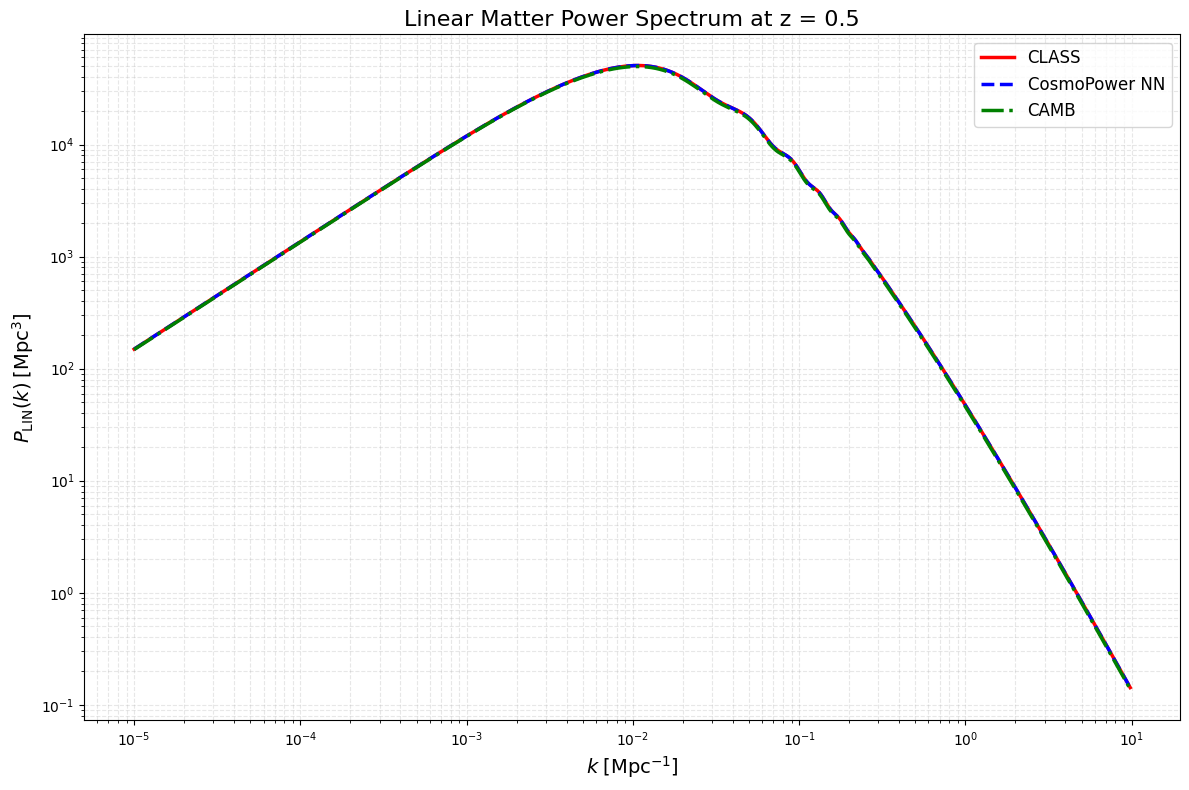

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.interpolate import interp1d
import cosmopower as cp
import camb
from camb import model

# Set up directories
os.makedirs("home", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Download the pre-trained CosmoPower model (run once)
if not os.path.exists("home/PKLIN_NN.pkl"):
    os.system("gdown --id 1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie -O home/PKLIN_NN.pkl")

# Load pre-trained NN model for linear P(k)
cp_nn = cp.cosmopower_NN(restore=True, restore_filename='home/PKLIN_NN')
k_modes = cp_nn.modes  # in 1/Mpc

# Cosmological parameters
cosmo_params = {
    'omega_b': 0.0225,
    'omega_cdm': 0.113,
    'h': 0.7,
    'n_s': 0.96,
    'ln10^{10}A_s': 3.07,
    'z': 0.5
}

# ----------------- COSMOPOWER -----------------
spectrum_cp = cp_nn.ten_to_predictions_np({
    'omega_b': [cosmo_params['omega_b']],
    'omega_cdm': [cosmo_params['omega_cdm']],
    'h': [cosmo_params['h']],
    'n_s': [cosmo_params['n_s']],
    'ln10^{10}A_s': [cosmo_params['ln10^{10}A_s']],
    'z': [cosmo_params['z']]
})[0]  # shape: (len(k_modes),)

# ----------------- CLASS -----------------
cosmo_class = Class()
params_class = {
    'output': 'mPk',
    'z_max_pk': 5,
    'P_k_max_1/Mpc': 10.,
    'nonlinear_min_k_max': 100.,  #related to setting non-linear effects or limits in the CLASS computation?
    'N_ncdm': 0,
    'omega_b': cosmo_params['omega_b'],
    'omega_cdm': cosmo_params['omega_cdm'],
    'h': cosmo_params['h'],
    'n_s': cosmo_params['n_s'],
    'ln10^{10}A_s': cosmo_params['ln10^{10}A_s'],
}
cosmo_class.set(params_class)
cosmo_class.compute()
spectrum_class = np.array([cosmo_class.pk(ki, cosmo_params['z']) for ki in k_modes])  #might compute the non-linear spectrum?
cosmo_class.struct_cleanup()
cosmo_class.empty()

# ----------------- CAMB -----------------
pars = camb.CAMBparams()
pars.set_cosmology(H0=cosmo_params['h']*100,
                   ombh2=cosmo_params['omega_b'],
                   omch2=cosmo_params['omega_cdm'])
pars.InitPower.set_params(ns=cosmo_params['n_s'],
                          As=np.exp(cosmo_params['ln10^{10}A_s'])*1e-10)
pars.set_matter_power(redshifts=[cosmo_params['z']], kmax=max(k_modes))
pars.NonLinear = model.NonLinear_none

results = camb.get_results(pars)
kh, z_vals, Pkh = results.get_matter_power_spectrum(
    minkh=min(k_modes)/cosmo_params['h'],
    maxkh=max(k_modes)/cosmo_params['h'],
    npoints=len(k_modes)
)

# Convert CAMB output from (k [h/Mpc], P [Mpc^3/h^3]) to (k [1/Mpc], P [Mpc^3])
h = cosmo_params['h']
k_camb = kh * h  # h/Mpc -> 1/Mpc
P_camb = Pkh[0] / h**3  # Mpc^3/h^3 -> Mpc^3

# Interpolate to match the same k_modes
interp_camb = interp1d(k_camb, P_camb, kind='cubic', bounds_error=False, fill_value='extrapolate')
spectrum_camb = interp_camb(k_modes)

# ----------------- PLOT -----------------
plt.figure(figsize=(12, 8))
plt.loglog(k_modes, spectrum_class, 'red', linewidth=2.5, label='CLASS')
plt.loglog(k_modes, spectrum_cp, 'blue', linestyle='--', linewidth=2.5, label='CosmoPower NN')
plt.loglog(k_modes, spectrum_camb, 'green', linestyle='-.', linewidth=2.5, label='CAMB')

plt.xlabel(r'$k \; [\mathrm{Mpc}^{-1}]$', fontsize=14)
plt.ylabel(r'$P_{\mathrm{LIN}}(k) \; [\mathrm{Mpc}^3]$', fontsize=14)
plt.title('Linear Matter Power Spectrum at z = 0.5', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('plots/matter_power_spectrum_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

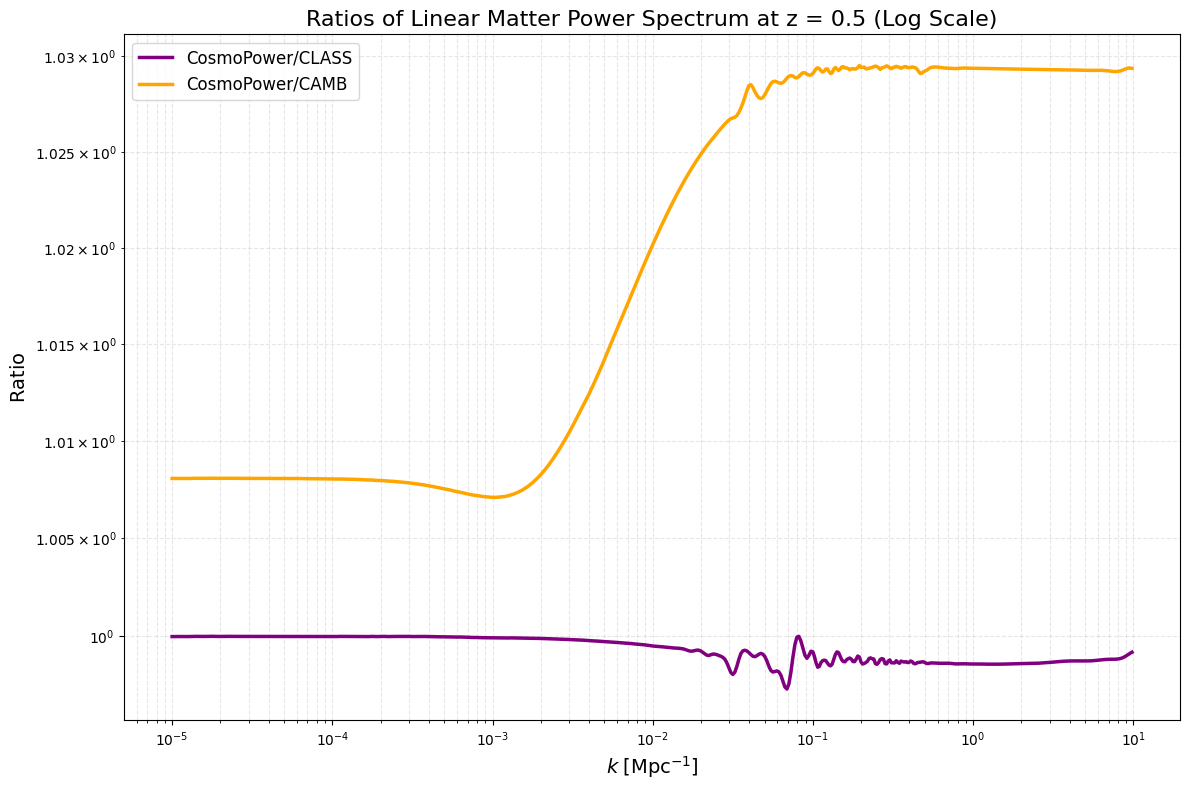

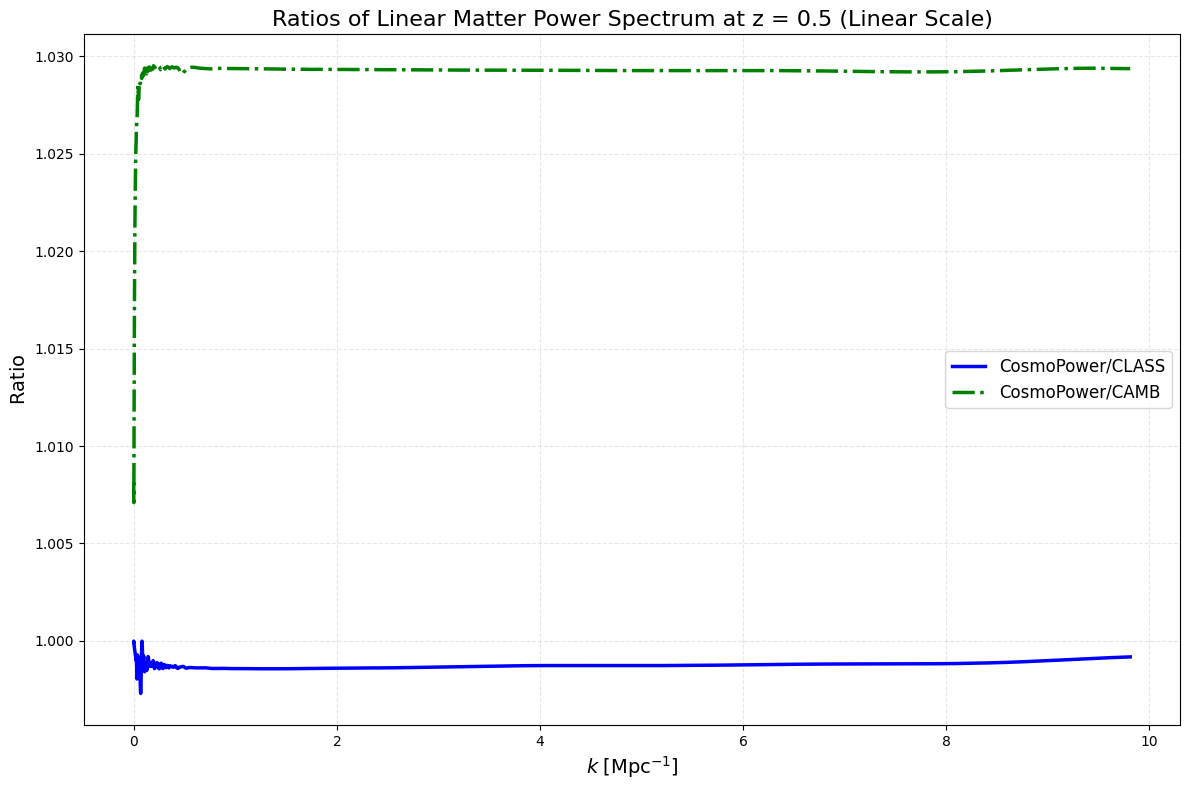

In [5]:
# Function to plot ratios
def plot_ratios(k_modes, spectrum_cp, spectrum_class, spectrum_camb, scale, filename):
    plt.figure(figsize=(12, 8))

    # Plot ratios based on the scale
    if scale == 'log':
        plt.loglog(k_modes, spectrum_cp / spectrum_class, 'purple', lw=2.5, label='CosmoPower/CLASS')
        plt.loglog(k_modes, spectrum_cp / spectrum_camb, 'orange', lw=2.5, label='CosmoPower/CAMB')
    else:
        plt.plot(k_modes, spectrum_cp / spectrum_class, 'blue', linestyle='-', linewidth=2.5, label='CosmoPower/CLASS')
        plt.plot(k_modes, spectrum_cp / spectrum_camb, 'green', linestyle='-.', linewidth=2.5, label='CosmoPower/CAMB')

    plt.xlabel(r"$k\;[{\rm Mpc}^{-1}]$", fontsize=14)
    plt.ylabel(r"$\text{Ratio}$", fontsize=14)
    plt.title(f"Ratios of Linear Matter Power Spectrum at z = 0.5 ({scale.capitalize()} Scale)", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    
    # Save and show the plot
    plt.savefig(f'plots/power_spectrum_ratios_{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot both log-log and linear scale ratios
plot_ratios(k_modes, spectrum_cp, spectrum_class, spectrum_camb, 'log', 'loglog')
plot_ratios(k_modes, spectrum_cp, spectrum_class, spectrum_camb, 'linear', 'linear')